<div style="text-align: left;">
    <img src="../images/Virtuelle_Hochschule_Bayern_logo.svg" alt="ZenBite Picture" style="width: 20%; max-width: 20%; margin-top: 30px; margin-bottom: 20px; float: left;">
    <div style="clear: both;"></div>
</div>

<div class='bar_title'></div>

<span style="color: #E59635; font-size: 56px;">Data-Driven Supply Chain Management</span>

## Session 3a - Assignment 

<br>

<span style="color: #7F7F7F;">*Data-Driven Decisions Group (D3)*</span>

## Import Libraries

In [1]:
from dscm.session3 import *


In [2]:
# Just for better display of the graphs

from IPython.display import display, Javascript

disable_autoscroll_js = """
IPython.OutputArea.prototype._should_scroll = function(lines) {
    return false;
}
"""

display(Javascript(disable_autoscroll_js))

<IPython.core.display.Javascript object>

In the lecture you have learned how to develop a more flexible model that can be used to find the optimal order quantity for each weekday. You also learned something about the 
phenomenon of overfitting when using a model that is too complex.
This was the case when we used a separate model for each month/weekday combination.
In the end we discussed some strategies to avoid overfitting.
 In this assignment we will revisit these strategies and apply them to our model.





**Recap:**
**How can we prevent overfitting in our model?**

* Option 1: Replace the month of the year with a feature indicating the season (e.g., winter, spring, summer, fall).
* Option 2: Replace the weekday with a feature indicating the weekend.(Monday to Friday->Weekday, Saturday and Sunday->Weekend)
* Option 3: Collect more historical data 

Import the data for the zenbite restaurant. 

In [3]:
zenbite = load_zenbite()
demand_chicken = zenbite.target['chicken']
features = zenbite.data
features.head()

,weekday,month,year,is_holiday,is_closed,weekend,wind,clouds,rain,sunshine,temperature
0,FRI,OCT,2022,0,0,0,1.9,7.7,0.1,150,15.9
1,SAT,OCT,2022,0,0,1,2.7,6.9,10.7,0,13.2
2,SUN,OCT,2022,0,0,1,1.4,8.0,0.4,0,10.6
3,MON,OCT,2022,0,0,0,2.3,6.4,0.0,176,13.3
4,TUE,OCT,2022,0,0,0,1.7,8.0,0.0,0,13.5


Perform a train-test split on the data. The first 500 days will be used for training and the remaining days for testing.

In [4]:
features

,weekday,month,year,is_holiday,is_closed,weekend,wind,clouds,rain,sunshine,temperature
0,FRI,OCT,2022,0,0,0,1.9,7.7,0.1,150,15.9
1,SAT,OCT,2022,0,0,1,2.7,6.9,10.7,0,13.2
2,SUN,OCT,2022,0,0,1,1.4,8.0,0.4,0,10.6
3,MON,OCT,2022,0,0,0,2.3,6.4,0.0,176,13.3
4,TUE,OCT,2022,0,0,0,1.7,8.0,0.0,0,13.5
...,...,...,...,...,...,...,...,...,...,...,...
710,MON,SEP,2024,0,0,0,3.7,6.4,0.1,208,18.4
711,TUE,SEP,2024,0,0,0,3.1,7.0,0.0,82,17.3
712,WED,SEP,2024,0,0,0,3.0,7.6,0.5,4,18.0
713,THU,SEP,2024,0,0,0,3.2,4.7,3.0,61,14.0


In [5]:
train = range(500)
test = range(500, 715)

cu = 15 
co = 5

# Task 1: Replace the month of the year with a feature indicating the season (e.g., winter, spring, summer, fall).



In this task, you will replace the month of the year with a feature indicating the season (e.g., winter, spring, summer, fall).
You will then train a model on each season/weekday combination and evaluate the performance of the model on the test set.

First, we will implement the model to approximate the sample average based on the day of the week feature, which is identical to the one that we introduced in the lecture. Your task then is to implement the model for each season/weekday combination.

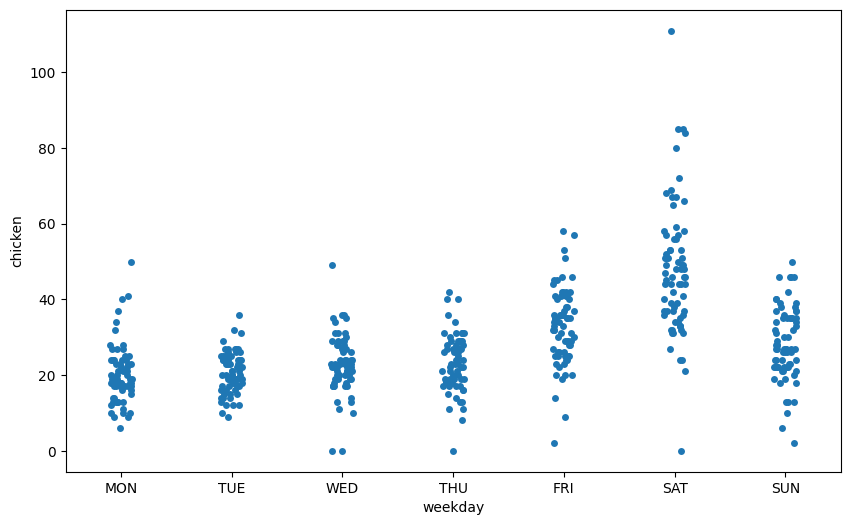

In [6]:
# Define the weekdays   
weekdays = ['MON', 'TUE', 'WED', 'THU', 'FRI', 'SAT', 'SUN']

# Plot the demand for chicken for each weekday
plot_demand_per_day(features, demand_chicken, train, weekdays)


Lets start importing the SAA model. 

In [7]:

SAA=SampleAverageApproximationNewsvendor(cu, co)


Now let's use the code from the lecture to implement the model for each weekday.

In [8]:

q_SAA_weekday = pd.Series(index=weekdays)

SAA = SampleAverageApproximationNewsvendor(cu,co)

for day in weekdays:
    
    demand_weekday = demand_chicken[train][features['weekday'][train] == day]
    
    SAA.fit(demand_weekday)
    quantity = SAA.predict().item()

    q_SAA_weekday.loc[day] = int(quantity)

The optimal order quantity for each weekday is given by


In [9]:
q_SAA_weekday

MON    24.0
TUE    24.0
WED    28.0
THU    28.0
FRI    40.0
SAT    56.0
SUN    35.0
dtype: float64

We now have given the weekday model as a pandas Series that maps each weekday to the corresponding order quantity.
To evaluate the performance of the model, we have to look up the order quantity for each day in the test set and calculate the average costs.

In [10]:
# Look up the demand for chicken for each weekday using the predict method
q = predict(features.loc[test], q_SAA_weekday, criteria = "weekday", keys = weekdays)

# Compute the cost of the policy
average_costs(demand_chicken[test], q, cu, co)

np.float64(61.2093023255814)

Now it is your turn to implement the model for each season/weekday combination.
We will help you with the first step by defining the different season weekday combinations.
This is done just like we did in the lecture for the month/weekday combinations.

In [11]:
seasons = ['WINTER', 'SPRING', 'SUMMER', 'AUTUMN']
seasons_weekdays = [season + '_' + weekday for season in seasons for weekday in weekdays]

seasons_weekdays

['WINTER_MON',
 'WINTER_TUE',
 'WINTER_WED',
 'WINTER_THU',
 'WINTER_FRI',
 'WINTER_SAT',
 'WINTER_SUN',
 'SPRING_MON',
 'SPRING_TUE',
 'SPRING_WED',
 'SPRING_THU',
 'SPRING_FRI',
 'SPRING_SAT',
 'SPRING_SUN',
 'SUMMER_MON',
 'SUMMER_TUE',
 'SUMMER_WED',
 'SUMMER_THU',
 'SUMMER_FRI',
 'SUMMER_SAT',
 'SUMMER_SUN',
 'AUTUMN_MON',
 'AUTUMN_TUE',
 'AUTUMN_WED',
 'AUTUMN_THU',
 'AUTUMN_FRI',
 'AUTUMN_SAT',
 'AUTUMN_SUN']

Now we add both the season and the season/weekday combination to the features data frame.

In [12]:
# Add a new feature: Season 
month_to_season = {'JAN': 'WINTER', 'FEB': 'WINTER', 'MAR': 'SPRING', 'APR': 'SPRING', 'MAY': 'SPRING', 'JUN': 'SUMMER', 'JUL': 'SUMMER', 'AUG': 'SUMMER', 'SEP': 'AUTUMN', 'OCT': 'AUTUMN', 'NOV': 'AUTUMN', 'DEC': 'WINTER'}
# Create season feature from month
features['season'] = features['month'].map(month_to_season)


# Add a new feature: Combination of season and weekday
features['season_weekday'] = features['season'].astype(str) + '_' + features['weekday'].astype(str)
features

,weekday,month,year,is_holiday,is_closed,weekend,wind,clouds,rain,sunshine,temperature,season,season_weekday
0,FRI,OCT,2022,0,0,0,1.9,7.7,0.1,150,15.9,AUTUMN,AUTUMN_FRI
1,SAT,OCT,2022,0,0,1,2.7,6.9,10.7,0,13.2,AUTUMN,AUTUMN_SAT
2,SUN,OCT,2022,0,0,1,1.4,8.0,0.4,0,10.6,AUTUMN,AUTUMN_SUN
3,MON,OCT,2022,0,0,0,2.3,6.4,0.0,176,13.3,AUTUMN,AUTUMN_MON
4,TUE,OCT,2022,0,0,0,1.7,8.0,0.0,0,13.5,AUTUMN,AUTUMN_TUE
...,...,...,...,...,...,...,...,...,...,...,...,...,...
710,MON,SEP,2024,0,0,0,3.7,6.4,0.1,208,18.4,AUTUMN,AUTUMN_MON
711,TUE,SEP,2024,0,0,0,3.1,7.0,0.0,82,17.3,AUTUMN,AUTUMN_TUE
712,WED,SEP,2024,0,0,0,3.0,7.6,0.5,4,18.0,AUTUMN,AUTUMN_WED
713,THU,SEP,2024,0,0,0,3.2,4.7,3.0,61,14.0,AUTUMN,AUTUMN_THU


Then we will plot the demand for each season/weekday combination.

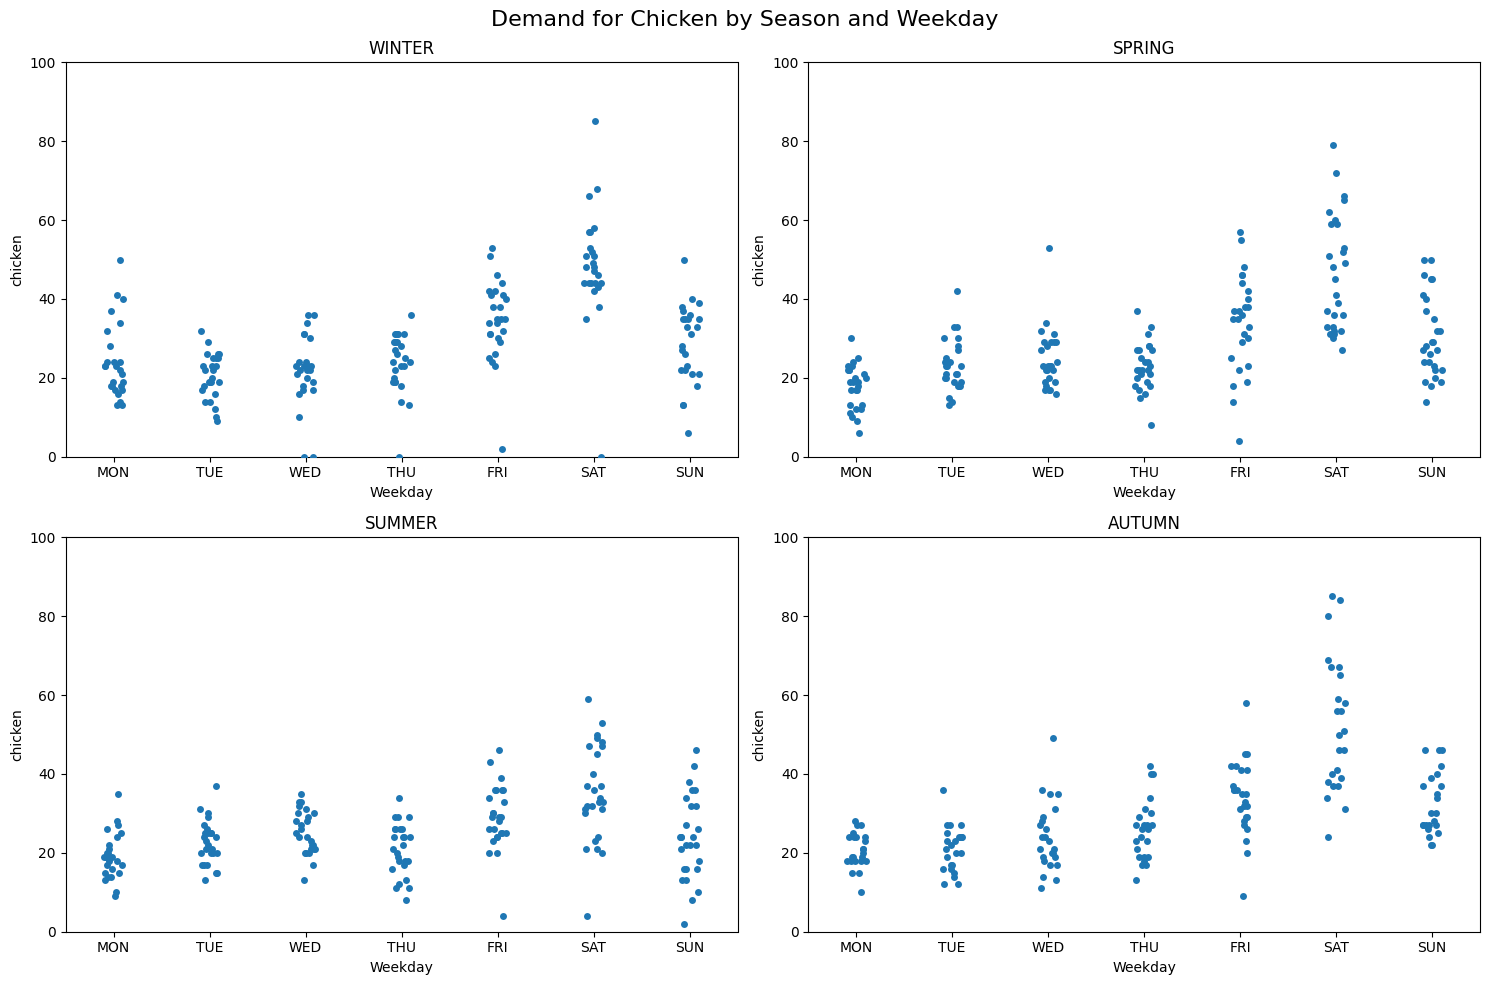

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt


# Make 4 plots, one for each season
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
# Add a title for all the plots 
fig.suptitle('Demand for Chicken by Season and Weekday', fontsize=16)

for i, season in enumerate(seasons):
    ax = axes[i // 2, i % 2]
    
    # Get the demand for chicken for the current season on the training set
    demand_chicken_season = demand_chicken[features[features['season'] == season].index]
    features_season = features[features['season'] == season]

    # Make a sns.stripplot
    sns.stripplot(x=features_season['weekday'], y=demand_chicken_season, ax=ax, jitter=True, dodge=True, order=weekdays)
    ax.set_title(season)
    ax.set_xlabel('Weekday')

    # Set y axis from 0 to 100
    ax.set_ylim(0, 100)

plt.tight_layout()

# Add a title for all the plot
plt.show()


Now you have to loop over all season/weekday combinations and fit a SAA model to each of them.


### Question 1.1 What is the optimal order quantity under this model for each weekday in winter?

In [14]:
# This has to be done by the student

# Calculate the optimal order quantity for each weekday in winter by fitting a SAA model to each season/weekday combination on the training set. 

seasons_weekdays[:5]

# Create a series to store the optimal order quantity for each season/weekday combination
q_SAA_season_weekday = pd.Series(index=seasons_weekdays)


# Steps to follow:
# Create a for loop over the season/weekday combinations and fit a SAA model to the demand for chicken for each combination
# Store the optimal order quantity in the q_SAA_season_weekday series


In [14]:
q_SAA_season_weekday = pd.Series(index=seasons_weekdays)
SAA = SampleAverageApproximationNewsvendor(cu, co)
for season_weekday in seasons_weekdays:
    demand_season_weekday = demand_chicken[train][features['season_weekday'][train] == season_weekday]
    SAA.fit(demand_season_weekday)
    quantity = SAA.predict().item()
    q_SAA_season_weekday.loc[season_weekday] = int(quantity)

After you have implemented the model for each season/weekday combination, you look up the order quantity for each weekday in the winter season to answer this question.

In [15]:
# Get the winter season (assuming that you have saved the optimal order quantities for each season/weekday combination in the q_SAA_season_weekday series)
q_SAA_season_weekday.loc[['WINTER_MON', 'WINTER_TUE', 'WINTER_WED', 'WINTER_THU', 'WINTER_FRI', 'WINTER_SAT', 'WINTER_SUN']]

WINTER_MON    32.0
WINTER_TUE    25.0
WINTER_WED    24.0
WINTER_THU    29.0
WINTER_FRI    41.0
WINTER_SAT    57.0
WINTER_SUN    36.0
dtype: float64

# Interpretation
For most winter weekdays, the optimal quantities remain relatively similar to the weekday-only model. This indicates that weekday is already an informative feature for capturing demand patterns, while the additional seasonal information only leads to moderate adjustments for most days. However, some weekdays, such as Monday, appear to be more affected by seasonal effects, suggesting that winter Mondays may systematically differ from the average Monday demand. 

Submit the solution using the `submit_answer_to_question11` function. 

In [16]:
# The numbers are just placeholders, the student has to fill them with the correct values
submit_answer_to_question11({
                'WINTER_MON': 32,
                'WINTER_TUE': 25,
                'WINTER_WED': 24,
                'WINTER_THU': 29,
                'WINTER_FRI': 41,
                'WINTER_SAT': 57,
                'WINTER_SUN': 36
})

The answer has been saved locally. Please submit the assignment when you are done with all questions.


### Question 1.2 Which model do you think is the best for determining the optimal order quantity?

Evaluate the performance of the model on the test set and compare it with the model that uses the weekday feature only.

In [19]:
# This has to be done by the student 
q_season_weekday = predict(features.loc[test], q_SAA_season_weekday, criteria='season_weekday', keys=seasons_weekdays)
cost_season_weekday = average_costs(demand_chicken[test], q_season_weekday, cu, co)
cost_season_weekday

np.float64(75.4186046511628)

# Interpretation
Although adding the season feature still leads to overfitting compared to the simpler weekday-only model, the season-weekday model performs better than the previous month-weekday model. This suggests that aggregating months into seasons reduces model complexity and partially mitigates overfitting. However, the weekday-only model still achieves the lowest average cost and therefore remains the most effective solution among the tested models. 

Now compare the costs of this model with the results from the lecture

Evaluate the model and compare the results with the model with only the weekday feature.
When comparing the models, answer the following questions:
1. Which model has a better fit?
    - a) The model with weekday and season features
    - b) The model with only the weekday feature
2. How much cost can be saved by using the better model?
    - a) Less than 5%
    - b) Between 5% and 10%
    - c) More than 10%

In [20]:
# Submit your answer to the questions above by filling in the dictionary below
# Type `True` for the options that are correct and `False` for the options that are incorrect

submit_answer_to_question12({
    "Question1": {
        "a": False,
        "b": True,
    },
    "Question2": {
        "a": False,
        "b": False,
        "c": True,
    },
})

The answer has been saved locally. Please submit the assignment when you are done with all questions.


# Task 2: Replace the weekday with a feature indicating the weekend.

In this task, you will replace the weekday with a feature indicating the weekend. 
You will then train a model on each season/is_weekend combination and evaluate the performance of the model on the test set.

First, we will again adding the season/weekend combination to the features data frame.

Then we will plot the demand for each season/weekend combination.

In [21]:
is_weekend = ['WEEKDAY', 'WEEKEND']

season_is_weekend = [season + '_' + weekend for season in seasons for weekend in is_weekend]
season_is_weekend

['WINTER_WEEKDAY',
 'WINTER_WEEKEND',
 'SPRING_WEEKDAY',
 'SPRING_WEEKEND',
 'SUMMER_WEEKDAY',
 'SUMMER_WEEKEND',
 'AUTUMN_WEEKDAY',
 'AUTUMN_WEEKEND']

In [22]:


# Add a new feature: Weekend
weekday_to_weekend = {'MON': 'WEEKDAY', 'TUE': 'WEEKDAY', 'WED': 'WEEKDAY', 'THU': 'WEEKDAY', 'FRI': 'WEEKDAY', 'SAT': 'WEEKEND', 'SUN': 'WEEKEND'}
# Create weekend feature from weekday
features['weekend'] = features['weekday'].map(weekday_to_weekend)

# Add a new feature: Combination of season and weekend
features['season_weekend'] = features['season'].astype(str) + '_' + features['weekend'].astype(str)

features



,weekday,month,year,is_holiday,is_closed,weekend,wind,clouds,rain,sunshine,temperature,season,season_weekday,season_weekend
0,FRI,OCT,2022,0,0,WEEKDAY,1.9,7.7,0.1,150,15.9,AUTUMN,AUTUMN_FRI,AUTUMN_WEEKDAY
1,SAT,OCT,2022,0,0,WEEKEND,2.7,6.9,10.7,0,13.2,AUTUMN,AUTUMN_SAT,AUTUMN_WEEKEND
2,SUN,OCT,2022,0,0,WEEKEND,1.4,8.0,0.4,0,10.6,AUTUMN,AUTUMN_SUN,AUTUMN_WEEKEND
3,MON,OCT,2022,0,0,WEEKDAY,2.3,6.4,0.0,176,13.3,AUTUMN,AUTUMN_MON,AUTUMN_WEEKDAY
4,TUE,OCT,2022,0,0,WEEKDAY,1.7,8.0,0.0,0,13.5,AUTUMN,AUTUMN_TUE,AUTUMN_WEEKDAY
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
710,MON,SEP,2024,0,0,WEEKDAY,3.7,6.4,0.1,208,18.4,AUTUMN,AUTUMN_MON,AUTUMN_WEEKDAY
711,TUE,SEP,2024,0,0,WEEKDAY,3.1,7.0,0.0,82,17.3,AUTUMN,AUTUMN_TUE,AUTUMN_WEEKDAY
712,WED,SEP,2024,0,0,WEEKDAY,3.0,7.6,0.5,4,18.0,AUTUMN,AUTUMN_WED,AUTUMN_WEEKDAY
713,THU,SEP,2024,0,0,WEEKDAY,3.2,4.7,3.0,61,14.0,AUTUMN,AUTUMN_THU,AUTUMN_WEEKDAY


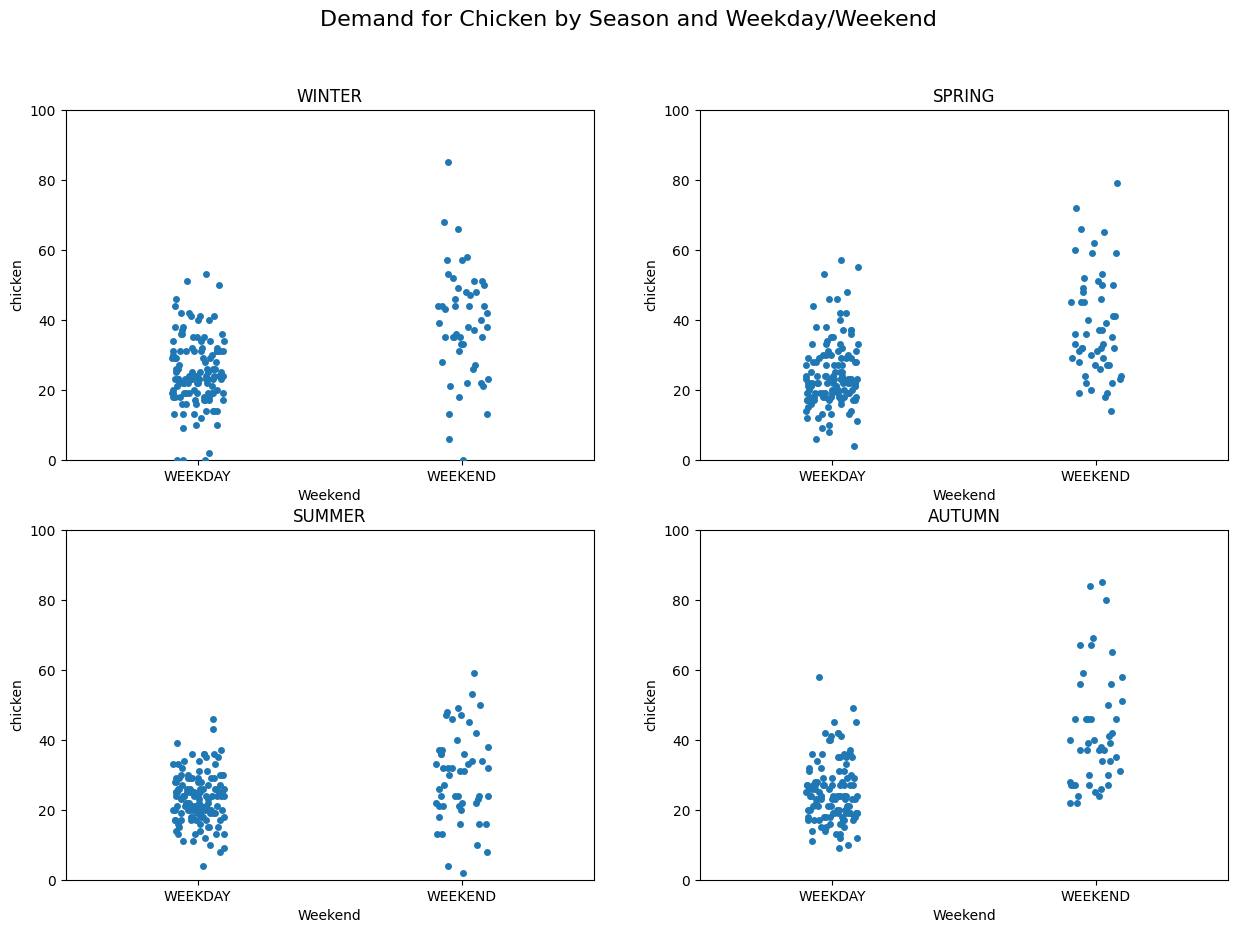

In [23]:
# Make 4 plots, one for each season
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
# Add a title for all the plots
fig.suptitle('Demand for Chicken by Season and Weekday/Weekend', fontsize=16)

for i, season in enumerate(seasons):
    ax = axes[i // 2, i % 2]
    
    # Get the demand for chicken for the current season on the training set
    demand_chicken_season = demand_chicken[features[features['season'] == season].index]
    features_season = features[features['season'] == season]

    # Make a sns.stripplot
    sns.stripplot(x=features_season['weekend'], y=demand_chicken_season, ax=ax, jitter=True, dodge=True,order = is_weekend)
    ax.set_title(season)
    ax.set_xlabel('Weekend')

    # Set y axis from 0 to 100
    ax.set_ylim(0, 100)


### Question 2.1 Which season has the highest optimal order quantity on weekends? Which season has the highest optimal order quantity on weekdays?

Your task again is to fit a SAA model to each season/weekend combination

In [24]:
# This has to be done by the student

q_SAA_season_weekend = pd.Series(index=season_is_weekend)


# Steps to follow:
# Create a for loop over the season/weekend combinations and fit a SAA model to the demand for chicken for each combination
# Fit the SAA model to the demand for chicken for each season/weekend combination on the training set
# Store the optimal order quantity in the q_SAA_season_weekend series





In [26]:
q_SAA_season_weekend = pd.Series(index=season_is_weekend)
SAA = SampleAverageApproximationNewsvendor(cu, co)
for season_weekend in season_is_weekend:
    demand_season_weekend = demand_chicken[train][features['season_weekend'][train] == season_weekend]
    SAA.fit(demand_season_weekend)
    quantity = SAA.predict().item()
    q_SAA_season_weekend.loc[season_weekend] = int(quantity)

In [28]:
# Get the order quantities for each season during the weekend and the weekdays 
# (assuming that you have saved the optimal order quantities for each season/weekend combination in the q_SAA_season_weekend series)
q_SAA_season_weekend.loc[['WINTER_WEEKDAY', 'WINTER_WEEKEND', 'SPRING_WEEKDAY', 'SPRING_WEEKEND', 'SUMMER_WEEKDAY', 'SUMMER_WEEKEND', 'AUTUMN_WEEKDAY', 'AUTUMN_WEEKEND']]

WINTER_WEEKDAY    31.0
WINTER_WEEKEND    49.0
SPRING_WEEKDAY    25.0
SPRING_WEEKEND    39.0
SUMMER_WEEKDAY    26.0
SUMMER_WEEKEND    37.0
AUTUMN_WEEKDAY    30.0
AUTUMN_WEEKEND    56.0
dtype: float64

# Interpretation 
The highest optimal order quantity on weekends is observed in autumn, while the highest weekday quantity is observed in winter. Across all seasons, weekend quantities are higher than weekday quantities, indicating that the weekend feature captures an important demand pattern.

Submit the solution using the `submit_answer_to_question21` function. Provide the optimal order quantities for each season on weekdays and weekend

In [29]:
# The boolean values are just placeholders, the student has to fill them with the correct values
submit_answer_to_question21({
    'WINTER_WEEKDAY': 31,
    'WINTER_WEEKEND': 49,
    'SPRING_WEEKDAY': 25,
    'SPRING_WEEKEND': 39,
    'SUMMER_WEEKDAY': 26,
    'SUMMER_WEEKEND': 37,
    'AUTUMN_WEEKDAY': 30,
    'AUTUMN_WEEKEND': 56,
})

The answer has been saved locally. Please submit the assignment when you are done with all questions.


### Question 2.2 Would you recommend using the season/is_weekend model to determine the optimal order quantity?

Evaluate the performance of the model on the test set and compare it with the performance of the models from the lecture. You do not need to compare it with the model from Task 1.
You can assume that the performance of the best model that we covered in the lecture is the weekday model. (With average costs of approximately 61)

In [30]:
# This has to be done by the student
q_season_weekend = predict(features.loc[test], q_SAA_season_weekend, criteria='season_weekend', keys=season_is_weekend)
cost_season_weekend = average_costs(demand_chicken[test], q_season_weekend, cu, co)
cost_season_weekend

np.float64(81.0)

# Interpretation 
Compared to the weekday-only model, the season/is_weekend model results in substantially higher average costs. By reducing the original seven weekday categories to only two categories (weekday and weekend), the model becomes simpler but also loses important information about demand differences between individual weekdays. As a result, the model may underfit the data and fail to capture relevant demand patterns. Compared to the other tested models, the weekday-only model appears to represent the best trade-off between model complexity and predictive performance, making it the sweet spot model in this assignment.

Submit the solution using the `submit_answer_to_question22` function. Type in True if you would recommend using the season/is_weekend model, otherwise type in False.

In [36]:
# The boolean values are just placeholders, the student has to fill them with the correct values
submit_answer_to_question22(recommendation=False)

The answer has been saved locally. Please submit the assignment when you are done with all questions.


### Question 2.3 How can we even further improve the SAA model?

Which of the following strategies would you recommend to further improve the model? What features would you include instead to get a better SAA model. **Hint:** Have a look at the different plots in the lecture.

* Option 1: The days of the week have similar demand patterns. However, the demand on saturdays is higher then the demand of the rest of the days. Therefore, we should use a separate SAA model for saturdays and a SAA model for the remaining days.

* Option 2: The days of the week have similar demand patterns. However, the demand on monday is lower than the demand of the rest of the days. Therefore, we should use a separate SAA model for mondays and a model for the remaining days.

* Option 3: We can use a SAA model that takes into account the differnt demand patterns during the different months of the year instead of the seasons. This would lower the complexity of the SAA model and therefore reduce the risk of overfitting.

Submit the solution using the `submit_answer_to_question23` function. For each option type `True` if you would recommend it, otherwise type `False`.

In [32]:
# The boolean values are just placeholders, the student has to fill them with the correct values
submit_answer_to_question23(option_1=True, option_2 = False, option_3 = False)

The answer has been saved locally. Please submit the assignment when you are done with all questions.


# Interpretation 
I would recommend option 1 because Saturday demand is clearly higher than the demand on most other days. Therefore, seperating Saturdays from the remaining days could capture an important demand pattern without introducing as much complexity as the mont- weekday model. However, the previous experiments also showed that increasing the number of groups can lead to overfitting. Therefore, even this additional segmentation may only provide limited improvements compared to the simpler weekday-only model. 

I would not recommend option 2 because Monday demand does not appear to differ as consistently or as strongly as Saturday demand. Creating a separate model for Mondays would therefore likely add unnecessary complexity without substantial improvements.

For the last option, we already tested a more granular month-based segmentation in the lecture, and it resulted in worse performance due to overfitting. Therefore, increasing the granularity again by using months instead of seasons is unlikely to improve the SAA model.